# 02 - Explorative Datenanalyse: Forex-Daten (EODHD API)

**Ziel:** Forex-Kursdaten von EODHD laden, erkunden und erste Qualitaetspruefung durchfuehren.

**Währungspaare:** EUR/USD, EUR/CHF, GBP/USD

**Datenquelle:** EODHD API (https://eodhd.com)

**API-Dokumentation:** https://eodhd.com/financial-apis/api-for-historical-data-and-volumes

---

## 1. Setup und Imports

In [1]:
# Bibliotheken importieren
import requests              # HTTP-Anfragen an die API
import pandas as pd          # Datenverarbeitung
import numpy as np           # Numerische Berechnungen
import matplotlib.pyplot as plt  # Visualisierung
import seaborn as sns        # Erweiterte Visualisierung
import os                    # Dateipfade
from dotenv import load_dotenv  # API-Key aus .env laden

# Darstellung konfigurieren
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print('Setup erfolgreich!')

Setup erfolgreich!


## 2. API-Key laden

Der API-Key wird aus der `.env` Datei geladen (wird nicht ins Git hochgeladen).

In [2]:
# .env Datei laden - verschiedene Pfade testen
import pathlib

for env_path in ['../.env', '.env', str(pathlib.Path.home() / 'Documents/GitHub/datawrangling/.env')]:
    if os.path.exists(env_path):
        load_dotenv(dotenv_path=env_path, override=True)
        print(f'.env gefunden unter: {env_path}')
        break

# API-Key auslesen
api_key = os.getenv('EODHD_API_KEY')

if api_key and api_key != 'dein_api_key_hier':
    print(f'API-Key geladen (beginnt mit: {api_key[:4]}...)')
else:
    print('FEHLER: Kein API-Key gefunden!')
    print(f'Aktuelles Verzeichnis: {os.getcwd()}')

.env gefunden unter: /Users/jeremynathan/Documents/GitHub/datawrangling/.env
API-Key geladen (beginnt mit: 6917...)


## 3. Daten laden von EODHD API

Die EODHD API liefert Forex-Daten im Format:

`https://eodhd.com/api/eod/EURUSD.FOREX?from=2024-01-01&to=2025-12-31&period=d&api_token=KEY&fmt=json`

Die Antwort ist ein JSON-Array mit: date, open, high, low, close, adjusted_close, volume

In [3]:
# Konfiguration: Währungspaare und Zeitraum (gleich wie Yahoo Finance!)
CURRENCY_PAIRS = {
    'EURUSD.FOREX': 'EUR/USD',
    'EURCHF.FOREX': 'EUR/CHF',
    'GBPUSD.FOREX': 'GBP/USD',
}

START_DATE = '2022-01-01'
END_DATE = '2026-03-18'

print(f'Zeitraum: {START_DATE} bis {END_DATE}')
print(f'Währungspaare: {list(CURRENCY_PAIRS.values())}')

Zeitraum: 2022-01-01 bis 2026-03-18
Währungspaare: ['EUR/USD', 'EUR/CHF', 'GBP/USD']


In [4]:
# Daten von der EODHD API laden
forex_data = {}

for eodhd_symbol, pair_name in CURRENCY_PAIRS.items():
    print(f'Lade {pair_name} ({eodhd_symbol})...')
    
    # API-URL und Parameter zusammenbauen
    url = f'https://eodhd.com/api/eod/{eodhd_symbol}'
    params = {
        'from': START_DATE,
        'to': END_DATE,
        'period': 'd',
        'api_token': api_key,
        'fmt': 'json'
    }
    
    # HTTP-GET Request ausführen
    response = requests.get(url, params=params)
    
    # Status prüfen
    if response.status_code == 200:
        data = response.json()
        df = pd.DataFrame(data)
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')
        forex_data[pair_name] = df
        print(f'  -> {len(df)} Zeilen geladen')
    else:
        print(f'  -> FEHLER: HTTP {response.status_code}')

print('\nAlle Daten geladen!')

Lade EUR/USD (EURUSD.FOREX)...
  -> 1377 Zeilen geladen
Lade EUR/CHF (EURCHF.FOREX)...
  -> 1145 Zeilen geladen
Lade GBP/USD (GBPUSD.FOREX)...
  -> 1380 Zeilen geladen

Alle Daten geladen!


## 4. Erste Datenübersicht

In [5]:
# Übersicht für jedes Währungspaar
for pair_name, df in forex_data.items():
    print(f'\n{"=" * 50}')
    print(f'{pair_name}')
    print(f'{"=" * 50}')
    print(f'Shape (Zeilen x Spalten): {df.shape}')
    print(f'Zeitraum: {df.index.min()} bis {df.index.max()}')
    print(f'Spalten: {list(df.columns)}')
    print(f'Datentypen:\n{df.dtypes}')
    print(f'\nErste 3 Zeilen:')
    display(df.head(3))


EUR/USD
Shape (Zeilen x Spalten): (1377, 6)
Zeitraum: 2022-01-02 00:00:00 bis 2026-03-17 00:00:00
Spalten: ['open', 'high', 'low', 'close', 'adjusted_close', 'volume']
Datentypen:
open              float64
high              float64
low               float64
close             float64
adjusted_close    float64
volume              int64
dtype: object

Erste 3 Zeilen:


,open,high,low,close,adjusted_close,volume
date,,,,,,
2022-01-02,1.1373,1.1379,1.1367,1.1373,1.1373,73
2022-01-03,1.1373,1.1376,1.1280,1.1302,1.1302,841
2022-01-04,1.1302,1.1323,1.1273,1.1283,1.1283,281



EUR/CHF
Shape (Zeilen x Spalten): (1145, 6)
Zeitraum: 2022-01-03 00:00:00 bis 2026-03-18 00:00:00
Spalten: ['open', 'high', 'low', 'close', 'adjusted_close', 'volume']
Datentypen:
open              float64
high              float64
low               float64
close             float64
adjusted_close    float64
volume              int64
dtype: object

Erste 3 Zeilen:


,open,high,low,close,adjusted_close,volume
date,,,,,,
2022-01-03,1.0372,1.0391,1.0349,1.0372,1.0372,0
2022-01-04,1.0379,1.0383,1.0335,1.0379,1.0379,0
2022-01-05,1.0337,1.0384,1.0335,1.0337,1.0337,0



GBP/USD
Shape (Zeilen x Spalten): (1380, 6)
Zeitraum: 2022-01-02 00:00:00 bis 2026-03-17 00:00:00
Spalten: ['open', 'high', 'low', 'close', 'adjusted_close', 'volume']
Datentypen:
open              float64
high              float64
low               float64
close             float64
adjusted_close    float64
volume              int64
dtype: object

Erste 3 Zeilen:


,open,high,low,close,adjusted_close,volume
date,,,,,,
2022-01-02,1.3529,1.3535,1.3521,1.3522,1.3522,79
2022-01-03,1.3522,1.3530,1.3431,1.3483,1.3483,690
2022-01-04,1.3483,1.3558,1.3460,1.3530,1.3530,189


## 5. Datenqualitaetspruefung

In [6]:
# Fehlende Werte prüfen
print('FEHLENDE WERTE PRO WAEHRUNGSPAAR')
print('=' * 50)

for pair_name, df in forex_data.items():
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    
    print(f'\n{pair_name}:')
    if missing.sum() == 0:
        print('  Keine fehlenden Werte!')
    else:
        for col in df.columns:
            if missing[col] > 0:
                print(f'  {col}: {missing[col]} fehlend ({missing_pct[col]}%)')

FEHLENDE WERTE PRO WAEHRUNGSPAAR

EUR/USD:
  Keine fehlenden Werte!

EUR/CHF:
  Keine fehlenden Werte!

GBP/USD:
  Keine fehlenden Werte!


In [7]:
# Duplikate prüfen
print('DUPLIKATE PRO WAEHRUNGSPAAR')
print('=' * 50)

for pair_name, df in forex_data.items():
    dupes = df.index.duplicated().sum()
    print(f'{pair_name}: {dupes} Duplikate')

DUPLIKATE PRO WAEHRUNGSPAAR
EUR/USD: 0 Duplikate
EUR/CHF: 0 Duplikate
GBP/USD: 0 Duplikate


In [8]:
# Deskriptive Statistik
for pair_name, df in forex_data.items():
    print(f'\n{"=" * 50}')
    print(f'Deskriptive Statistik: {pair_name}')
    print(f'{"=" * 50}')
    display(df.describe())


Deskriptive Statistik: EUR/USD


,open,high,low,close,adjusted_close,volume
count,1377.000000,1377.000000,1377.000000,1377.000000,1377.000000,1.377000e+03
mean,1.093123,1.096607,1.089719,1.093202,1.093202,5.162272e+05
std,0.049789,0.049415,0.050183,0.049821,0.049821,3.016943e+06
min,0.959600,0.967100,0.953600,0.959600,0.959600,0.000000e+00
25%,1.062300,1.066300,1.058500,1.062400,1.062400,1.460000e+02
50%,1.086900,1.090000,1.083800,1.086900,1.086900,4.210000e+02
75%,1.131900,1.136500,1.128500,1.132400,1.132400,9.824600e+04
max,1.204000,1.208300,1.190600,1.204100,1.204100,3.043796e+07



Deskriptive Statistik: EUR/CHF


,open,high,low,close,adjusted_close,volume
count,1145.000000,1145.000000,1145.000000,1145.000000,1145.000000,1145.0
mean,0.962527,0.964883,0.960003,0.962530,0.962530,0.0
std,0.033151,0.033542,0.032741,0.033154,0.033154,0.0
min,0.897300,0.901000,0.896900,0.900200,0.900200,0.0
25%,0.936100,0.938200,0.934100,0.936100,0.936100,0.0
50%,0.956900,0.959000,0.954200,0.956900,0.956900,0.0
75%,0.981500,0.983800,0.979100,0.981500,0.981500,0.0
max,1.059800,1.061100,1.054900,1.059400,1.059400,0.0



Deskriptive Statistik: GBP/USD


,open,high,low,close,adjusted_close,volume
count,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1.380000e+03
mean,1.275712,1.279781,1.271449,1.275717,1.275717,5.323897e+06
std,0.058028,0.057044,0.059102,0.057993,0.057993,1.012136e+07
min,1.072600,1.083800,1.034400,1.072600,1.072600,0.000000e+00
25%,1.240100,1.244550,1.235725,1.240075,1.240075,1.810000e+02
50%,1.271650,1.275050,1.268500,1.271650,1.271650,5.360000e+02
75%,1.327800,1.331600,1.324925,1.327800,1.327800,1.578525e+06
max,1.382700,1.386800,1.375000,1.382700,1.382700,4.198349e+07


## 6. Visualisierung

### 6.1 Kursverlauf (Close-Preis)

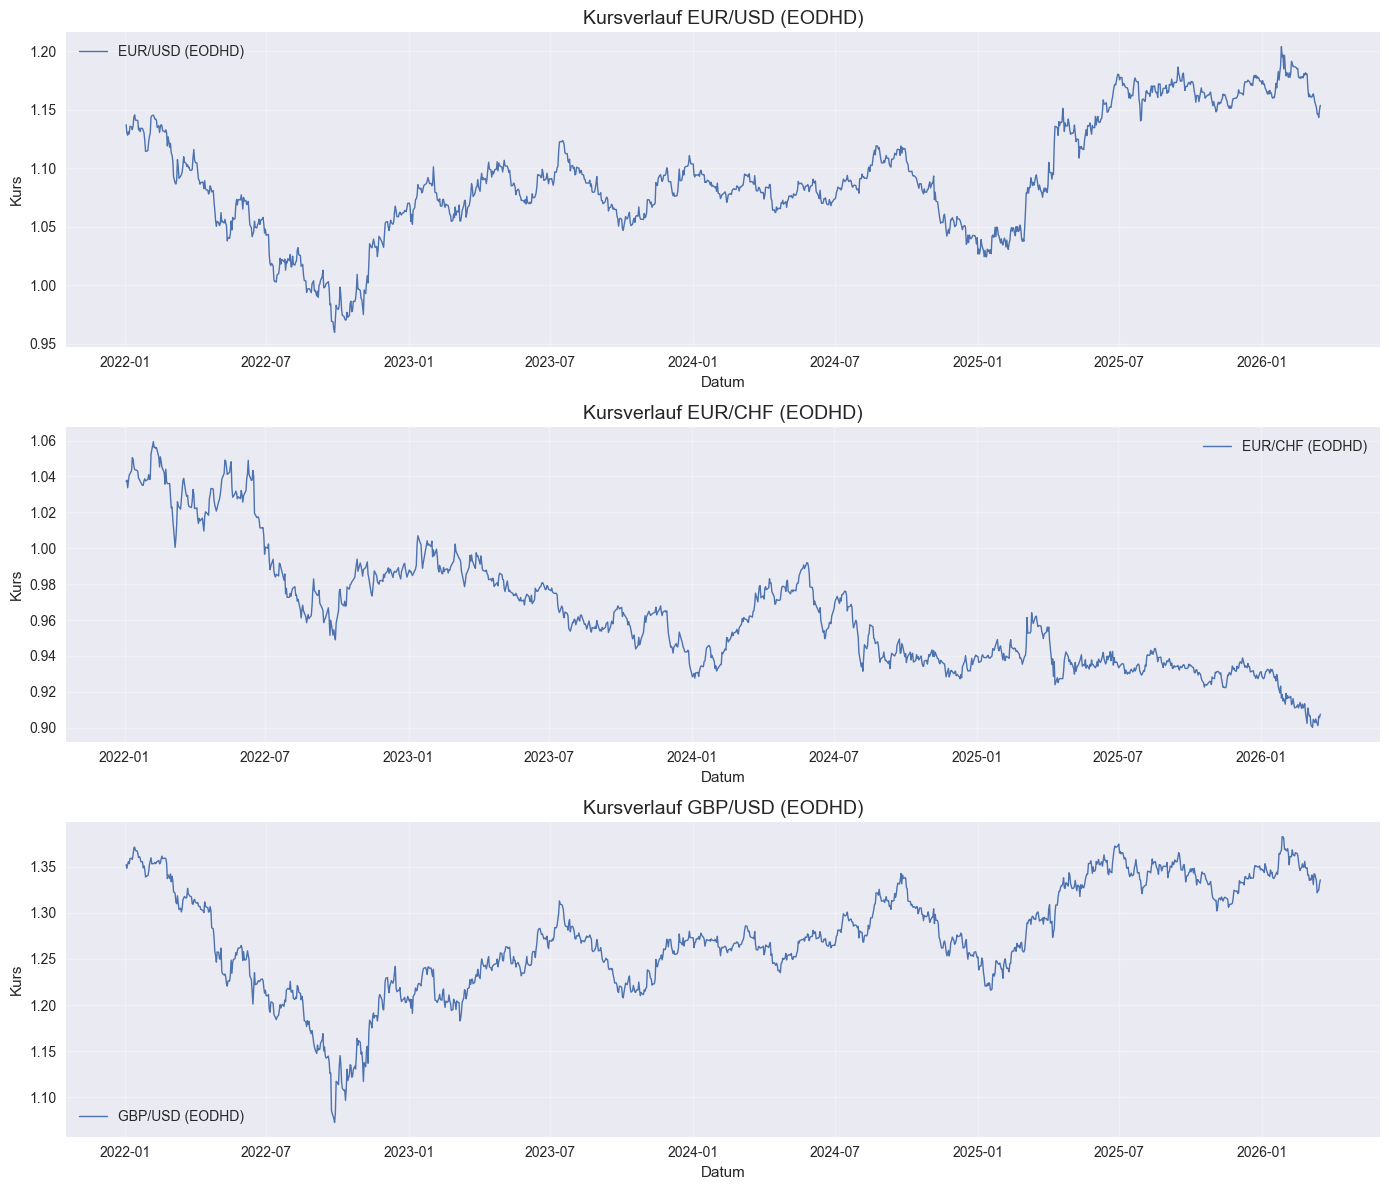

In [9]:
# Kursverlauf plotten
fig, axes = plt.subplots(len(forex_data), 1, figsize=(14, 4 * len(forex_data)))

if len(forex_data) == 1:
    axes = [axes]

for ax, (pair_name, df) in zip(axes, forex_data.items()):
    ax.plot(df.index, df['close'], label=f'{pair_name} (EODHD)', linewidth=1)
    ax.set_title(f'Kursverlauf {pair_name} (EODHD)', fontsize=14)
    ax.set_xlabel('Datum')
    ax.set_ylabel('Kurs')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Verteilung der täglichen Renditen

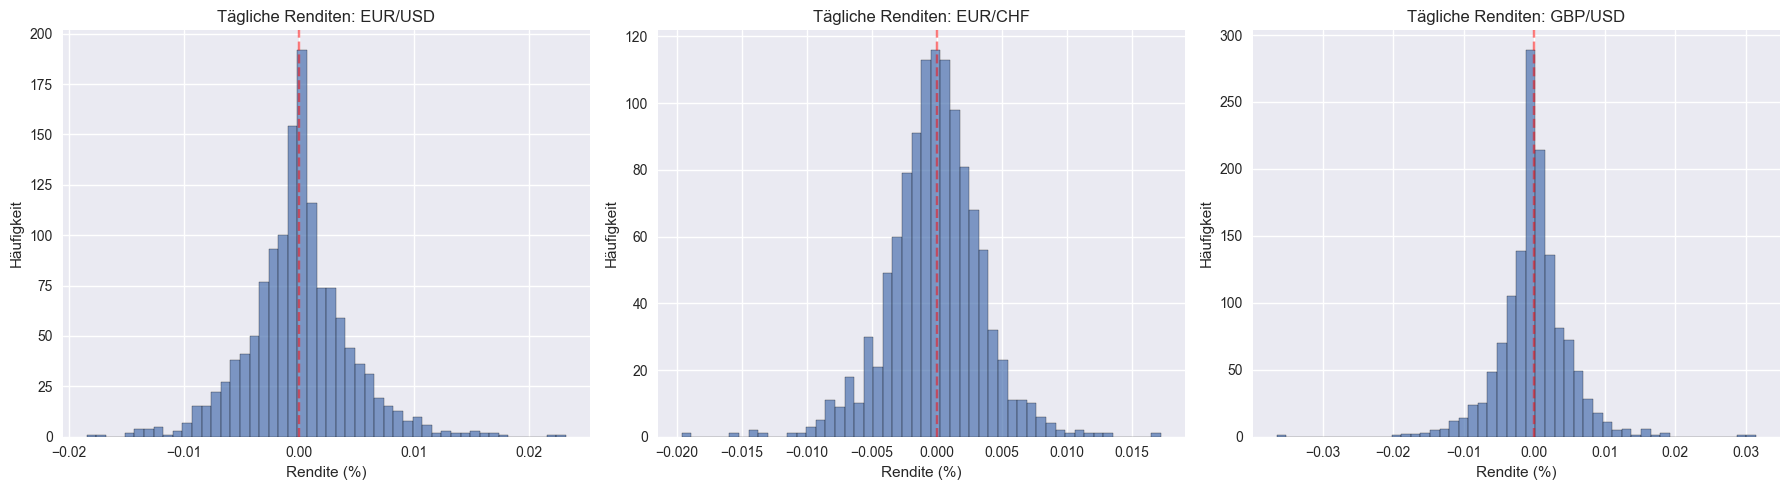

In [10]:
# Tägliche Renditen
fig, axes = plt.subplots(1, len(forex_data), figsize=(6 * len(forex_data), 5))

if len(forex_data) == 1:
    axes = [axes]

for ax, (pair_name, df) in zip(axes, forex_data.items()):
    returns = df['close'].pct_change().dropna()
    ax.hist(returns, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'Tägliche Renditen: {pair_name}', fontsize=12)
    ax.set_xlabel('Rendite (%)')
    ax.set_ylabel('Häufigkeit')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 6.3 Fehlende Tage identifizieren

In [11]:
# Alle fehlenden Tage anzeigen
for pair_name, df in forex_data.items():
    print(f'\n{"=" * 50}')
    print(f'{pair_name}')
    print(f'{"=" * 50}')
    
    all_days = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    missing_days = all_days.difference(df.index)
    missing_weekends = [d for d in missing_days if d.weekday() >= 5]
    missing_weekdays = [d for d in missing_days if d.weekday() < 5]
    
    print(f'Gesamte fehlende Tage:     {len(missing_days)}')
    print(f'  davon Wochenenden:       {len(missing_weekends)}')
    print(f'  davon Wochentage:        {len(missing_weekdays)}')
    
    if len(missing_weekdays) > 0:
        print(f'\n  Fehlende Wochentage (Feiertage etc.):')
        for d in missing_weekdays:
            day_name = ['Mo', 'Di', 'Mi', 'Do', 'Fr'][d.weekday()]
            print(f'    {d.strftime("%Y-%m-%d")} ({day_name})')


EUR/USD
Gesamte fehlende Tage:     159
  davon Wochenenden:       159
  davon Wochentage:        0

EUR/CHF
Gesamte fehlende Tage:     391
  davon Wochenenden:       391
  davon Wochentage:        0

GBP/USD
Gesamte fehlende Tage:     156
  davon Wochenenden:       156
  davon Wochentage:        0


## 7. Rohdaten speichern

In [ ]:
# Rohdaten als CSV speichern
OUTPUT_DIR = '../../data/raw/forex/eodhd'
os.makedirs(OUTPUT_DIR, exist_ok=True)

for pair_name, df in forex_data.items():
    safe_name = pair_name.replace('/', '_')
    filename = f'{safe_name}_{START_DATE}_to_{END_DATE}.csv'
    filepath = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(filepath)
    print(f'Gespeichert: {filepath} ({len(df)} Zeilen)')

print('\nAlle Rohdaten gespeichert!')

## 8. Zusammenfassung

### Erkenntnisse aus der EDA:
- **Datenumfang:** (hier Ergebnisse eintragen nach Ausfuehrung)
- **Fehlende Werte:** (hier Ergebnisse eintragen)
- **Duplikate:** (hier Ergebnisse eintragen)
- **Auffaelligkeiten:** (hier Ergebnisse eintragen)

### Nächste Schritte:
1. Datenqualitaet zwischen Yahoo und EODHD vergleichen
2. Daten bereinigen und harmonisieren
3. Nachrichten laden (EODHD News API + Webscraping)